# Loan Amount Prediction — Two-Stage Model
**Stage 1 (classification):** was the loan approved (amount > 0) or not?

**Stage 2 (regression):** given approval, how much? Compare Linear, Ridge, Lasso, ElasticNet.

We split it this way because rows with `Loan Sanction Amount (USD) == 0` aren't "small loans" — they're rejected/unprocessed applications. Mixing them into one regression forces a single line to fit two different underlying processes.

## 1. Load the dataset

In [1]:
import kagglehub
import pandas as pd

path = kagglehub.dataset_download("phileinsophos/predict-loan-amount-data")
df = pd.read_csv(path + "/train.csv")
df = df.dropna(subset=["Loan Sanction Amount (USD)"])
df.head()

,Customer ID,Name,Gender,Age,Income (USD),Income Stability,Profession,Type of Employment,Location,Loan Amount Request (USD),...,Credit Score,No. of Defaults,Has Active Credit Card,Property ID,Property Age,Property Type,Property Location,Co-Applicant,Property Price,Loan Sanction Amount (USD)
0,C-36995,Frederica Shealy,F,56,1933.05,Low,Working,Sales staff,Semi-Urban,72809.58,...,809.44,0,NaN,746,1933.05,4,Rural,1,119933.46,54607.18
1,C-33999,America Calderone,M,32,4952.91,Low,Working,NaN,Semi-Urban,46837.47,...,780.40,0,Unpossessed,608,4952.91,2,Rural,1,54791.00,37469.98
2,C-3770,Rosetta Verne,F,65,988.19,High,Pensioner,NaN,Semi-Urban,45593.04,...,833.15,0,Unpossessed,546,988.19,2,Urban,0,72440.58,36474.43
3,C-26480,Zoe Chitty,F,65,NaN,High,Pensioner,NaN,Rural,80057.92,...,832.70,1,Unpossessed,890,NaN,2,Semi-Urban,1,121441.51,56040.54
4,C-23459,Afton Venema,F,31,2614.77,Low,Working,High skill tech staff,Semi-Urban,113858.89,...,745.55,1,Active,715,2614.77,4,Semi-Urban,1,208567.91,74008.28


## 2. Preprocessing
- Drop ID columns and the buggy `Property Age` column
- Impute missing values (median for numeric, mode for categorical)
- One-hot encode categorical columns

In [2]:
df_clean = df.drop(columns=['Customer ID', 'Name', 'Property ID', 'Property Age'])

num_cols = df_clean.select_dtypes(include=['number']).columns
df_clean[num_cols] = df_clean[num_cols].fillna(df_clean[num_cols].median())

cat_cols = df_clean.select_dtypes(include=['object']).columns
for col in cat_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

df_final = pd.get_dummies(df_clean, drop_first=True)
print(df_final.shape)

(29660, 45)


## 3. Exploratory Data Analysis

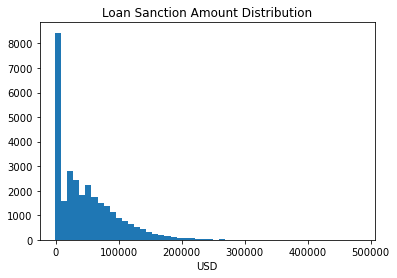

Zero-amount rows: 7865 (26.5% of data)


Loan Sanction Amount (USD)     1.000000
Loan Amount Request (USD)      0.726408
Property Price                 0.687181
Current Loan Expenses (USD)    0.483610
Credit Score                   0.359701
Income (USD)                   0.033811
Age                            0.008112
Dependents                     0.004788
Property Type                  0.001984
No. of Defaults               -0.004330
Co-Applicant                  -0.006945
Name: Loan Sanction Amount (USD), dtype: float64

In [3]:
import matplotlib.pyplot as plt

plt.hist(df_final['Loan Sanction Amount (USD)'], bins=50)
plt.title('Loan Sanction Amount Distribution')
plt.xlabel('USD')
plt.show()

n_zero = (df_final['Loan Sanction Amount (USD)'] == 0).sum()
print(f"Zero-amount rows: {n_zero} ({n_zero / len(df_final) * 100:.1f}% of data)")

df_clean[num_cols].corr()['Loan Sanction Amount (USD)'].sort_values(ascending=False)

## 4. Create the approval label
`Approved = 1` if `Loan Sanction Amount (USD) > 0`, else `0`.

In [4]:
df_final['Approved'] = (df_final['Loan Sanction Amount (USD)'] > 0).astype(int)
df_final['Approved'].value_counts()

1    21457
0     8203
Name: Approved, dtype: int64

## 5. Stage 1 — Classification: was the loan approved?

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

X_clf = df_final.drop(columns=['Loan Sanction Amount (USD)', 'Approved'])
y_clf = df_final['Approved']

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

numeric_feature_cols = [c for c in num_cols if c in X_clf.columns]

clf_scaler = StandardScaler()
Xc_train_scaled = Xc_train.copy()
Xc_test_scaled = Xc_test.copy()
Xc_train_scaled[numeric_feature_cols] = clf_scaler.fit_transform(Xc_train[numeric_feature_cols])
Xc_test_scaled[numeric_feature_cols] = clf_scaler.transform(Xc_test[numeric_feature_cols])

clf = LogisticRegression(max_iter=1000)
clf.fit(Xc_train_scaled, yc_train)
yc_pred = clf.predict(Xc_test_scaled)

print("Accuracy:", accuracy_score(yc_test, yc_pred))
print(classification_report(yc_test, yc_pred))

/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


Accuracy: 0.8192852326365475
              precision    recall  f1-score   support

           0       0.82      0.45      0.58      1641
           1       0.82      0.96      0.89      4291

    accuracy                           0.82      5932
   macro avg       0.82      0.70      0.73      5932
weighted avg       0.82      0.82      0.80      5932



## 6. Stage 2 — Regression: predict amount, approved loans only
From here on we work only with rows where `Approved == 1`.

In [6]:
df_approved = df_final[df_final['Approved'] == 1].drop(columns=['Approved'])

X = df_approved.drop(columns=['Loan Sanction Amount (USD)'])
y = df_approved['Loan Sanction Amount (USD)']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

reg_scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numeric_feature_cols] = reg_scaler.fit_transform(X_train[numeric_feature_cols])
X_test_scaled[numeric_feature_cols] = reg_scaler.transform(X_test[numeric_feature_cols])

## 7. Baseline models: Linear, Ridge, Lasso, ElasticNet

In [7]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

def evaluate(model, X_tr, y_tr, X_te, y_te, name):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    mse = mean_squared_error(y_te, y_pred)
    return {'Model': name, 'MSE': mse, 'RMSE': np.sqrt(mse), 'R2': r2_score(y_te, y_pred)}

models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=1.0, max_iter=10000),
    'ElasticNet': ElasticNet(alpha=1.0, l1_ratio=0.5, max_iter=10000)
}

results = [evaluate(m, X_train_scaled, y_train, X_test_scaled, y_test, name) for name, m in models.items()]
results_df = pd.DataFrame(results)
results_df

,Model,MSE,RMSE,R2
0,Linear Regression,3.148510e+07,5611.158880,0.985010
1,Ridge,3.145926e+07,5608.855370,0.985023
2,Lasso,3.136109e+07,5600.097612,0.985069
3,ElasticNet,4.683786e+08,21642.055419,0.777011


## 8. Hyperparameter tuning with 5-fold cross-validation

In [8]:
from sklearn.model_selection import GridSearchCV

param_grids = {
    'Ridge': {'alpha': [0.01, 0.1, 1, 10, 50, 100]},
    'Lasso': {'alpha': [0.01, 0.1, 1, 10, 50, 100]},
    'ElasticNet': {'alpha': [0.01, 0.1, 1, 10, 50], 'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]}
}

tuned_estimators = {
    'Ridge': Ridge(),
    'Lasso': Lasso(max_iter=10000),
    'ElasticNet': ElasticNet(max_iter=10000)
}

best_models = {}
tuned_results = []
for name, est in tuned_estimators.items():
    grid = GridSearchCV(est, param_grids[name], scoring='neg_mean_squared_error', cv=5, n_jobs=-1)
    grid.fit(X_train_scaled, y_train)
    best_models[name] = grid.best_estimator_
    row = evaluate(grid.best_estimator_, X_train_scaled, y_train, X_test_scaled, y_test, f'{name} (tuned)')
    row['Best Params'] = grid.best_params_
    tuned_results.append(row)

tuned_results_df = pd.DataFrame(tuned_results)
tuned_results_df

/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"
/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"
/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"
/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"
/usr/lib/python3/dist-packages/scipy

,Model,MSE,RMSE,R2,Best Params
0,Ridge (tuned),3.145926e+07,5608.855370,0.985023,{'alpha': 1}
1,Lasso (tuned),3.069052e+07,5539.902731,0.985389,{'alpha': 10}
2,ElasticNet (tuned),3.140029e+07,5603.595836,0.985051,"{'alpha': 0.01, 'l1_ratio': 0.9}"


## 9. Feature selection with Lasso
Lasso can shrink irrelevant feature coefficients to exactly zero. Drop those features, then refit Ridge and ElasticNet on the reduced feature set to see if removing noise features helps.

In [9]:
lasso_best = best_models['Lasso']
lasso_coefs = pd.Series(lasso_best.coef_, index=X_train_scaled.columns)

zero_features = lasso_coefs[lasso_coefs == 0].index.tolist()
kept_features = lasso_coefs[lasso_coefs != 0].index.tolist()

print(f"Lasso zeroed out {len(zero_features)} of {len(lasso_coefs)} features")
print("Dropped:", zero_features)

Lasso zeroed out 25 of 44 features
Dropped: ['Age', 'Co-Applicant', 'Gender_M', 'Profession_Maternity leave', 'Profession_Student', 'Profession_Unemployed', 'Type of Employment_Cleaning staff', 'Type of Employment_Cooking staff', 'Type of Employment_Core staff', 'Type of Employment_Drivers', 'Type of Employment_HR staff', 'Type of Employment_High skill tech staff', 'Type of Employment_IT staff', 'Type of Employment_Low-skill Laborers', 'Type of Employment_Managers', 'Type of Employment_Medicine staff', 'Type of Employment_Private service staff', 'Type of Employment_Realty agents', 'Type of Employment_Sales staff', 'Type of Employment_Secretaries', 'Type of Employment_Security staff', 'Type of Employment_Waiters/barmen staff', 'Has Active Credit Card_Unpossessed', 'Property Location_Semi-Urban', 'Property Location_Urban']


In [10]:
X_train_reduced = X_train_scaled[kept_features]
X_test_reduced = X_test_scaled[kept_features]

reduced_results = []
for name in ['Ridge', 'ElasticNet']:
    grid = GridSearchCV(tuned_estimators[name], param_grids[name],
                         scoring='neg_mean_squared_error', cv=5, n_jobs=-1)
    grid.fit(X_train_reduced, y_train)
    row = evaluate(grid.best_estimator_, X_train_reduced, y_train, X_test_reduced, y_test,
                    f'{name} (Lasso-reduced features)')
    row['Best Params'] = grid.best_params_
    reduced_results.append(row)

reduced_results_df = pd.DataFrame(reduced_results)
reduced_results_df

,Model,MSE,RMSE,R2,Best Params
0,Ridge (Lasso-reduced features),3.116833e+07,5582.860274,0.985161,{'alpha': 1}
1,ElasticNet (Lasso-reduced features),3.113909e+07,5580.241039,0.985175,"{'alpha': 0.01, 'l1_ratio': 0.9}"


## 10. Final comparison
Does removing the Lasso-zeroed features improve Ridge/ElasticNet, or does it just lose useful signal?

In [11]:
final = pd.concat([
    results_df,
    tuned_results_df.drop(columns=['Best Params']),
    reduced_results_df.drop(columns=['Best Params'])
], ignore_index=True)

final.sort_values('RMSE')

,Model,MSE,RMSE,R2
5,Lasso (tuned),3.069052e+07,5539.902731,0.985389
8,ElasticNet (Lasso-reduced features),3.113909e+07,5580.241039,0.985175
7,Ridge (Lasso-reduced features),3.116833e+07,5582.860274,0.985161
2,Lasso,3.136109e+07,5600.097612,0.985069
6,ElasticNet (tuned),3.140029e+07,5603.595836,0.985051
1,Ridge,3.145926e+07,5608.855370,0.985023
4,Ridge (tuned),3.145926e+07,5608.855370,0.985023
0,Linear Regression,3.148510e+07,5611.158880,0.985010
3,ElasticNet,4.683786e+08,21642.055419,0.777011
